# ChatBot Development Project
This project is purely experimental and intended to improve my portfolio.

I will use the "Bitext" data in this project. You can check the link https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset for it.

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bitext/bitext-gen-ai-chatbot-customer-support-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.87M/2.87M [00:01<00:00, 1.51MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/bitext/bitext-gen-ai-chatbot-customer-support-dataset/versions/1


In [5]:
import os
import pandas as pd

# The 'path' variable is a directory path.
dataset_directory = path

# Find CSV files in directory
csv_files = [f for f in os.listdir(dataset_directory) if f.endswith('.csv')]

if not csv_files:
    raise FileNotFoundError(f"CSV dosyasi bulunamadi: {dataset_directory} dizininde.")

# Use the first CSV file found (usually there is only one)
DATA_FILE_PATH = os.path.join(dataset_directory, csv_files[0])

# Check file existence (usually unnecessary after listdir and join, but good for error checking)
if not os.path.exists(DATA_FILE_PATH):
    raise FileNotFoundError(
        f"Veri dosyasi bulunamadi: {DATA_FILE_PATH}. Lutfen dizin icerigini kontrol edin."
    )

df = pd.read_csv(DATA_FILE_PATH)

In [6]:
df.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


Fields of the Dataset
Every record in the dataset contains the following fields:

flags: tags (explained below in the Language Generation Tags section)

instruction: User request originating from Customer Support domain

category: high-level semantic category of the intent

intent: intent corresponding to user instruction

response: sample expected reply from the virtual assistant


## Categories and Intents
The categories and intents covered by the dataset are:

Account: create_account, delete_account, edit_account, recover_password, registration_problems, switch_account

CANCELLATION_FEE: check_cancellation_fee

CONTACT: contact_customer_service, contact_human_agent

DELIVERY: delivery_options, delivery_period

FEEDBACK: complaint, review

INVOICE: check_invoice, get_invoice

ORDER: cancel_order, change_order, place_order, track_order

PAYMENT: check_payment_methods, payment_issue

REFUND: check_refund_policy, get_refund, track_refund

SHIPPING_ADDRESS: change_shipping_address, set_up_shipping_address

SUBSCRIPTION: newsletter_subscription

## Language Generation Tags

The dataset includes tags reflecting how language varies across different phenomena such as colloquial or offensive language. For example, if a "cancel_order" intent has a "COLLOQUIAL" tag, it will show an informal representation like: "can u cancel my order".

These tags specify the type of language variation expressed by the entry. These tags associated with each entry allow Conversational Designers to customize training datasets according to different user profiles with varied language use. Thanks to these tags, many different datasets can be created to make the resulting assistant more accurate and robust.

For example:

A bot selling sneakers should target a younger demographic using more casual/street language.

A classic retail banking bot, on the other hand, should use more formal or polite language.

The dataset also reflects linguistic phenomena frequently encountered in real-life virtual assistants, such as spelling mistakes, incorrectly joined words, and punctuation errors.

The dataset contains labeling for all relevant linguistic phenomena that can be used to customize models for different user profiles.

Lexical Variation Tags

M - Morphological variation: Inflectional and derivational changes.

Example: "is my SIM card active", "is my SIM card activated".

L - Semantic variations: Synonyms, hyphenations, compound words...

Example: "what’s my billing date", "what’s my anniversary date".

Syntactic Structure Variation Tags
B - Basic syntactic structure: Standard sentence layout.

Example: "activate my SIM card", "I need to activate my SIM card".

I - Interrogative structure: Question sentences.

Example: "can you activate my SIM card?", "how do I activate my SIM card?".

C - Coordinate syntactic structure: Sentences containing multiple clauses.

Example: "I have a new SIM card, what do I need to do to activate it?".

N - Negation: Sentences containing negation.

Example: "I do not want this item, where to cancel my order?".

Register/Style Variation Tags
P - Politeness variation: Polite expressions.

Example: "could you help me activate my SIM card, please?".

Q - Colloquial variation: Slang, chat language.

Example: "can u activ8 my SIM?".

W - Offensive language: Profanity or insults.

Example: "I want to talk to a f*&%*g agent".

Stylistic Variation Tags
K - Keyword mode: Robotic, speaking only with key phrases.

Example: "activate SIM", "new SIM".

E - Use of abbreviations:

Example: "I'm / I am interested...".

Z - Typos and Errors: Spelling issues, incorrect punctuation.

Example: "how can i activaet my card" (typo).

Other Tags Not Used in This Dataset
D - Indirect speech: "Tell my agent to activate my SIM card."

G - Regional variations: US English vs UK English ("truck" vs "lorry").

R - Respect structures: Language-specific variations.

Y - Code switching: Changing languages within a sentence. E.g.: "activer ma SIM card".

In [7]:
len(df)

26872

In [8]:
df[df.isnull().any(axis=1)]

,flags,instruction,category,intent,response


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   flags        26872 non-null  object
 1   instruction  26872 non-null  object
 2   category     26872 non-null  object
 3   intent       26872 non-null  object
 4   response     26872 non-null  object
dtypes: object(5)
memory usage: 1.0+ MB


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,flags,instruction,category,intent,response
count,26872,26872,26872,26872,26872
unique,394,24635,11,27,26870
top,BL,shiping to {{Delivery City}},ACCOUNT,contact_customer_service,"Firstly, I truly understand how pivotal the {{..."
freq,5212,8,5986,1000,2


In [12]:
df.isnull().sum()

,0
flags,0
instruction,0
category,0
intent,0
response,0


## About the Data
So far, there seems to be no missing values in the data. From now on, I will create new columns and shape the data according to the obtained information.

In [13]:
import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove placeholders like {{...}}
    # r'\{\{.*?\}\}' -> finds the shortest expression starting with {{ and ending with }}.
    text = re.sub(r'\{\{.*?\}\}', '', text)

    # Remove punctuation and special characters
    # [^\w\s] -> Remove everything that is NOT a word char or space.
    text = re.sub(r'[^\w\s]', '', text)

    # Clear extra spaces (e.g., "  " -> " ")
    text = text.strip()

    return text

# Apply function to 'instruction' column
df['clean_instruction'] = df['instruction'].apply(clean_text)

# Check the result
print(df[['instruction', 'clean_instruction']].head())

                                         instruction  \
0   question about cancelling order {{Order Number}}   
1  i have a question about cancelling oorder {{Or...   
2    i need help cancelling puchase {{Order Number}}   
3         I need to cancel purchase {{Order Number}}   
4  I cannot afford this order, cancel purchase {{...   

                            clean_instruction  
0             question about cancelling order  
1   i have a question about cancelling oorder  
2              i need help cancelling puchase  
3                   i need to cancel purchase  
4  i cannot afford this order cancel purchase  


In [14]:
df['intent'].value_counts()

,count
intent,
contact_customer_service,1000
complaint,1000
check_invoice,1000
switch_account,1000
edit_account,1000
contact_human_agent,999
check_payment_methods,999
delivery_period,999
newsletter_subscription,999


In [15]:
# We can use LabelEncoder to convert categorical data in the 'intent' column into numerical data.
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['encoded_intent'] = label_encoder.fit_transform(df['intent'])

In [16]:
df.head()

,flags,instruction,category,intent,response,clean_instruction,encoded_intent
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...,question about cancelling order,0
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...,i have a question about cancelling oorder,0
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...,i need help cancelling puchase,0
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...,i need to cancel purchase,0
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...,i cannot afford this order cancel purchase,0


# Data vectorizer
So far, I have checked for unknown values and applied text corrections. We will separate x and y while distributing the data. But before that, we need to tokenize it using TextVectorizer from tensorflow.keras.preprocessing.text.

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [18]:
# Create and fit Tokenizer
tokenizer = Tokenizer(
    num_words = 5000,
    filters = '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    oov_token = '<OOV>',
    )

In [19]:
tokenizer.fit_on_texts(df['clean_instruction'])
sequences = tokenizer.texts_to_sequences(df['clean_instruction'])

In [20]:
# Create padding
pad = pad_sequences(
    sequences,
    maxlen = 100,
    padding = 'post',
    truncating = 'post',
)

# Necessary parts for training are completed
Now let's split the data and slowly move to model building and training phases.

In [21]:
# Create train and test splits
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(pad, df['encoded_intent'], test_size=0.2, random_state=42)

X_train.shape

(21497, 100)

In [22]:
num_classes = df['encoded_intent'].nunique()
num_classes

27

In [23]:
# Build the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAvgPool1D
import tensorflow as tf


model_1 = Sequential([
    Embedding(input_dim=5000, output_dim=16, input_length=100),
    GlobalAvgPool1D(),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Doing great so far. We split the data into x and y arrays, applied tokenizer and sequencing padding to shape it via integers. We compiled the model, and now we will fit it using early stopping callbacks.

In [24]:
# Create EarlyStopping callback for model
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
)

In [25]:
# Train the model
history_1 = model_1.fit(
    X_train,
    y_train,
    epochs = 20,
    validation_data = (X_test, y_test),
    callbacks = [early_stopping]
)

Epoch 1/20
672/672 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.0710 - loss: 3.2704 - val_accuracy: 0.1529 - val_loss: 3.1778
Epoch 2/20
672/672 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2871 - loss: 2.7258 - val_accuracy: 0.4065 - val_loss: 2.2183
Epoch 3/20
672/672 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5714 - loss: 1.7923 - val_accuracy: 0.6500 - val_loss: 1.4693
Epoch 4/20
672/672 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7503 - loss: 1.2244 - val_accuracy: 0.8063 - val_loss: 1.0260
Epoch 5/20
672/672 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8368 - loss: 0.8595 - val_accuracy: 0.8688 - val_loss: 0.7171
Epoch 6/20
672/672 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8769 - loss: 0.6284 - val_accuracy: 0.8891 - val_loss: 0.5571
Epoch 7/20
672/672 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9027 - loss: 0.4811 - val_accuracy: 0.9139 - val_loss: 0.4151
Epoch 8/20
672/672 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9192 - loss: 0.3810 - val_accuracy: 0.

In [26]:
# Evaluate model on test set
model_1.evaluate(X_test, y_test)

168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9807 - loss: 0.0805


[0.08052757382392883, 0.9806511402130127]

In [27]:
import matplotlib.pyplot as plt

In [28]:
def plot_loss_curves(history):
  """
  Loss ile accuracy eğrilerini çizmek için bir fonksiyon.
  Parametre olarak model.fit() fonksiyonundan dönen history nesnesini alır ve eğitim ile doğrulama kaybı ve doğruluğunu görselleştirir.
  """
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

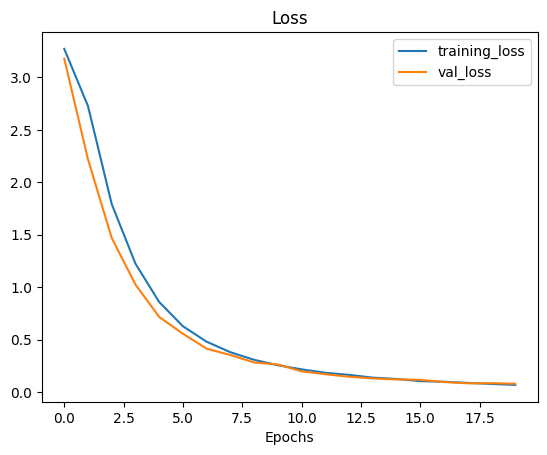

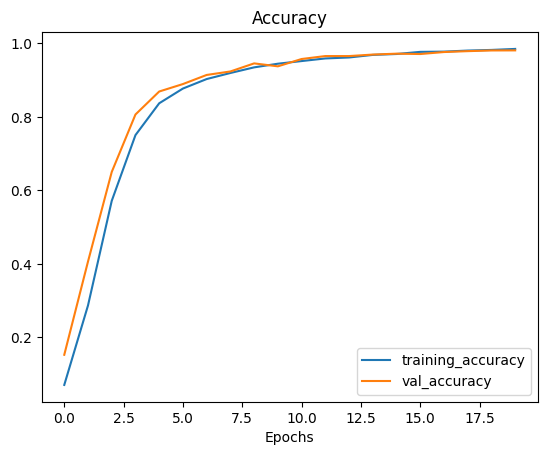

In [29]:
plot_loss_curves(history_1)

In [30]:
import numpy as np
def predict_intent(text):
  """
  Bu fonksiyon bir girdi alıp bu girdi üzerinden tahmin yapmaya yarıyor. Modelin eğitildiği dil gereği
  girdi ingilizce olmalıdır.
  """
  # Input is cleaned up using our clean_text function.
  text = clean_text(text)

  # converting text to numerical sequences (vectors)
  input_seq = tokenizer.texts_to_sequences([text])
  sequences = pad_sequences(input_seq, maxlen=100, padding='post', truncating='post')

  # The tokenized sentence is predicted by the model.
  prediction = model_1.predict(sequences)

  # Determined with the highest probability.
  predicted_class = np.argmax(prediction, axis=1)
  predicted_intent = label_encoder.inverse_transform(predicted_class)
  return predicted_intent[0]

In [31]:
predict_intent("I want to talk to someone immediately")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step


'contact_human_agent'

# Answer
The model now understands the category it receives. Now let's create the response generation part.

We can proceed in 2 ways here. You can create a python dict and fetch responses from it based on the returned intent.

Alternatively, you can generate answers using an LLM model. I will proceed with the 2nd approach here.
You can use local LLMs or APIs from large models like Gemini or ChatGPT to generate these answers.

In [32]:
%pip install transformers

In [33]:
df['intent'].value_counts()

,count
intent,
contact_customer_service,1000
complaint,1000
check_invoice,1000
switch_account,1000
edit_account,1000
contact_human_agent,999
check_payment_methods,999
delivery_period,999
newsletter_subscription,999


# Let's test it.
We previously created 'model_1', a model that can identify the intent, i.e., understand what we want when we input text.
Now let's generate answers with LLM based on the output from this model.

In [35]:
def generate_llm_response(intent):
    """
    Niyeti alır, sözlükten uygun rolü bulur ve LLM'e cevap ürettirir.
    If-Else yerine Sözlük (Dictionary) kullanarak kodu temiz tutarız.
    """

    # Assign a role to the model for each intent.
    prompt_templates = {
        # Order Procedures
        "cancel_order": "Customer Support: I understand you want to cancel. To proceed, please provide your ",
        "track_order": "Customer Support: Let me check the status. Can you share your ",
        "place_order": "Customer Support: I can help you place a new order. What item are you looking for ",
        "change_order": "Customer Support: To modify your order, I need to know your ",

        # Account and Payment Operations
        "check_invoice": "Customer Support: I can help you with your invoice. Please tell me your ",
        "payment_issue": "Customer Support: I apologize for the payment issue. Could you verify your ",
        "check_payment_methods": "Customer Support: We accept several payment methods including ",
        "switch_account": "Customer Support: To switch accounts, verification is needed. Please provide ",
        "recover_password": "Customer Support: To reset your password, please confirm your ",
        "delete_account": "Customer Support: I'm sad to see you go. To confirm account deletion, please enter ",
        "create_account": "Customer Support: To create a new account, I will need some basic information such as ",
        "edit_account": "Customer Support: To edit your account details, please provide your ",
        "registration_problems": "Customer Support: I'm sorry you're having trouble registering. Can you describe the issue with ",

        # Cargo and Delivery
        "delivery_period": "Customer Support: Our standard delivery time is usually ",
        "delivery_options": "Customer Support: We offer several delivery options such as ",
        "change_shipping_address": "Customer Support: To change your shipping address, please provide your new ",
        "set_up_shipping_address": "Customer Support: To set up a shipping address, please provide your ",

        # Communication and Complaints
        "contact_customer_service": "Customer Support: I will connect you to a human agent immediately. Please wait while ",
        "contact_human_agent": "Customer Support: I understand you'd like to speak with a human agent. Please hold while I connect you to ",
        "complaint": "Customer Support: I am very sorry to hear about your bad experience. Please tell me more about ",
        "review": "Customer Support: Thank you for your feedback! We would love to hear your thoughts on ",

        # Refund
        "get_refund": "Customer Support: I can assist with the refund process. Please provide your order number ",
        "check_refund_policy": "Customer Support: Our refund policy allows returns within ",
        "track_refund": "Customer Support: To track your refund, please provide your ",

        # Other
        "check_cancellation_fee": "Customer Support: To check for cancellation fees, I need your ",
        "newsletter_subscription": "Customer Support: To manage your newsletter subscription, please provide your email address. You can also ",
        "get_invoice": "Customer Support: To retrieve your invoice, please provide your "
    }

    # Fetch intent from dictionary, format default sentence if not found.
    default_prompt = "Customer Support: Hello! How can I assist you with "
    selected_prompt = prompt_templates.get(intent, default_prompt)

    # max_new_tokens: Length of the response (30-40 words is ideal)
    response = generator(selected_prompt, max_new_tokens=35, num_return_sequences=1, pad_token_id=50256)

    full_text = response[0]['generated_text']

    # Let's clean up the "Customer Support:" part.
    clean_reply = full_text.replace("Customer Support:", "").strip()

    return clean_reply

In [ ]:
# First pass the sentence to TensorFlow to predict the intent.
gelen_niyet = predict_intent("Where is my cargo?")
print(f"Modelin Bulduğu Niyet: {gelen_niyet}")

# Importing pipeline and initializing generator here
from transformers import pipeline
generator = pipeline('text-generation', model='distilgpt2')

# Let's pass the extracted intent to the LLM and get the output in return.
bot_cevabi = generate_llm_response(gelen_niyet)
print(f"Botun Cevabı: {bot_cevabi}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Modelin Bulduğu Niyet: delivery_options


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'pad_token_id', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=35) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Botun Cevabı: We offer several delivery options such as iced coffee and ice cream.


We provide a default template via dictionary based on the intent, but use GPT-2 to complete the response so it is not too robotic. This prevents repetitive robotic texts.
We provide a hybrid structure here. If we were using an API, we could pull a large language model and get better NLP responses combining this predefined dictionary.

# Model Save
You can save the model to use it in different domains. This allows us to export it out of colab. However, our goal will be to step beyond the terminal and develop a WebUI.

In [37]:
import pickle

print("--- Model ve Yardımcı Dosyalar Kaydediliyor... ---")

# 1. Save TensorFlow Model (Modern format: .keras)
model_1.save("chatbot_model.keras")
print("✅ Model kaydedildi: chatbot_model.keras")

# 2. Save Tokenizer (Pickling it)
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("✅ Tokenizer kaydedildi: tokenizer.pickle")

# 3. Save Label Encoder
with open('label_encoder.pickle', 'wb') as handle:
    pickle.dump(label_encoder, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("✅ Label Encoder kaydedildi: label_encoder.pickle")

print("--- Tüm kayıtlar tamamlandı! ---")

--- Model ve Yardımcı Dosyalar Kaydediliyor... ---
✅ Model kaydedildi: chatbot_model.keras
✅ Tokenizer kaydedildi: tokenizer.pickle
✅ Label Encoder kaydedildi: label_encoder.pickle
--- Tüm kayıtlar tamamlandı! ---


In [38]:
import re
import numpy as np
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import pipeline

# 1. Restore Saved Files
print("Sistem ayaga kaldiriliyor...")

model = load_model('chatbot_model.keras')

with open('tokenizer.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)

with open('label_encoder.pickle', 'rb') as handle:
    label_encoder = pickle.load(handle)

generator = pipeline('text-generation', model='distilgpt2')

print("Sistem hazir! (Egitim yapilmadi, hafizadan yuklendi)")

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\{\{.*?\}\}', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

def predict_intent(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=100, padding='post', truncating='post')
    pred = model.predict(padded, verbose=0)
    class_id = np.argmax(pred, axis=1)
    return label_encoder.inverse_transform(class_id)[0]

def generate_llm_response(intent):
    prompt_templates = {
        'cancel_order': 'Customer Support: I understand you want to cancel. To proceed, please provide your ',
        'track_order': 'Customer Support: Let me check the status. Can you share your ',
        'place_order': 'Customer Support: I can help you place a new order. What item are you looking for ',
        'change_order': 'Customer Support: To modify your order, I need to know your ',
        'check_invoice': 'Customer Support: I can help you with your invoice. Please tell me your ',
        'payment_issue': 'Customer Support: I apologize for the payment issue. Could you verify your ',
        'check_payment_methods': 'Customer Support: We accept several payment methods including ',
        'switch_account': 'Customer Support: To switch accounts, verification is needed. Please provide ',
        'recover_password': 'Customer Support: To reset your password, please confirm your ',
        'delete_account': 'Customer Support: I am sorry to see you go. To confirm account deletion, please enter ',
        'create_account': 'Customer Support: To create a new account, I need basic information such as ',
        'edit_account': 'Customer Support: To edit your account details, please provide your ',
        'registration_problems': 'Customer Support: I am sorry you are having registration problems. Can you describe the issue with ',
        'delivery_period': 'Customer Support: Our standard delivery time is usually ',
        'delivery_options': 'Customer Support: We offer several delivery options such as ',
        'change_shipping_address': 'Customer Support: To change your shipping address, please provide your new ',
        'set_up_shipping_address': 'Customer Support: To set up a shipping address, please provide your ',
        'contact_customer_service': 'Customer Support: I will connect you to a human agent immediately. Please wait while ',
        'contact_human_agent': 'Customer Support: I understand you want a human agent. Please hold while I connect you to ',
        'complaint': 'Customer Support: I am very sorry to hear about your experience. Please tell me more about ',
        'review': 'Customer Support: Thank you for your feedback! We would love to hear your thoughts on ',
        'get_refund': 'Customer Support: I can assist with the refund process. Please provide your order number ',
        'check_refund_policy': 'Customer Support: Our refund policy allows returns within ',
        'track_refund': 'Customer Support: To track your refund, please provide your ',
        'check_cancellation_fee': 'Customer Support: To check for cancellation fees, I need your ',
        'newsletter_subscription': 'Customer Support: To manage newsletter subscription, please provide your email address. You can also ',
        'get_invoice': 'Customer Support: To retrieve your invoice, please provide your '
    }

    selected_prompt = prompt_templates.get(intent, 'Customer Support: Hello! How can I assist you with ')
    response = generator(selected_prompt, max_new_tokens=35, num_return_sequences=1, pad_token_id=50256)
    full_text = response[0]['generated_text']
    return full_text.replace('Customer Support:', '').strip()

Sistem ayaga kaldiriliyor...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sistem hazir! (Egitim yapilmadi, hafizadan yuklendi)


In [39]:
q = "i need a human contact"
intent = predict_intent(q)
cevap = generate_llm_response(intent)
print(f"Bot ({intent}): {cevap}")

Both `max_new_tokens` (=35) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Bot (contact_human_agent): I understand you want a human agent. Please hold while I connect you to ____. The person I meet is a real person.




Follow them on twitter http://twitter.com/I_L_L_L_L
